# Persistent Trace Classifier

## Research question

Can a one-timestep visual input leave a persistent neuromorphic trace long enough for an SNN to classify MNIST digits 0–9 reliably?

## Initial experiment

Before training an SNN, verify that a one-timestep MNIST input can generate a useful decaying visual trace:

$$
M_t = \beta M_{t-1} + I_t
$$

where the physical image is present only at $t=0$.

For $t>0$, $I_t=0$, so the memory decays as:

$$
M_t = \beta^t I_0.
$$

Center-of-mass estimation and motion tracking are intentionally excluded from this notebook for now.

In [47]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.12.0
Device: mps


In [48]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /Users/alexeysolganik/Documents/PhD/Summer26/snn-moving-digit
Data directory: /Users/alexeysolganik/Documents/PhD/Summer26/snn-moving-digit/data


In [49]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


Image shape: torch.Size([1, 28, 28])
Label: 5
Min: 0.0
Max: 1.0


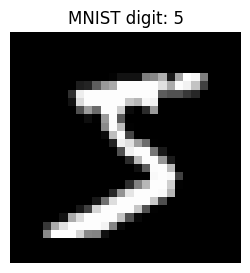

In [50]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Min:", image.min().item())
print("Max:", image.max().item())

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"MNIST digit: {label}")
plt.axis("off")
plt.show()

In [51]:
def persistent_trace(image, beta=0.9, num_steps=8):
    """
    Generate a decaying visual memory from a one-timestep physical input.

    Parameters
    ----------
    image : torch.Tensor
        Input image with shape [C, H, W].
    beta : float
        Memory decay factor.
    num_steps : int
        Number of internal timesteps.

    Returns
    -------
    torch.Tensor
        Trace sequence with shape [T, C, H, W].
    """
    memory = torch.zeros_like(image)
    trace = []

    for t in range(num_steps):
        if t == 0:
            input_t = image
        else:
            input_t = torch.zeros_like(image)

        memory = beta * memory + input_t
        trace.append(memory.clone())

    return torch.stack(trace)

In [52]:
beta = 0.9
num_steps = 8

trace = persistent_trace(
    image,
    beta=beta,
    num_steps=num_steps,
)

print(trace.shape)

torch.Size([8, 1, 28, 28])


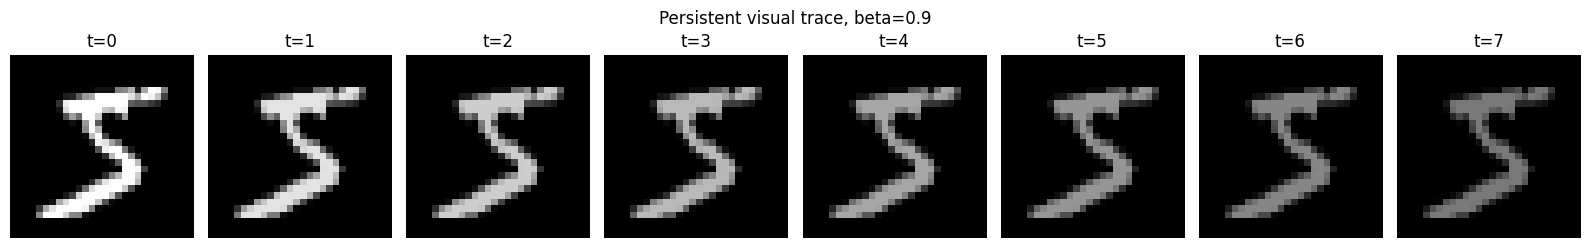

In [53]:
fig, axes = plt.subplots(1, num_steps, figsize=(16, 2.5))

for t, ax in enumerate(axes):
    ax.imshow(trace[t].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t={t}")
    ax.axis("off")

plt.suptitle(f"Persistent visual trace, beta={beta}")
plt.tight_layout()
plt.show()

In [54]:
initial_max = trace[0].max().item()

for t in range(num_steps):
    actual = trace[t].max().item()
    expected = initial_max * (beta ** t)

    print(
        f"t={t}: "
        f"actual={actual:.4f}, "
        f"expected={expected:.4f}"
    )

t=0: actual=1.0000, expected=1.0000
t=1: actual=0.9000, expected=0.9000
t=2: actual=0.8100, expected=0.8100
t=3: actual=0.7290, expected=0.7290
t=4: actual=0.6561, expected=0.6561
t=5: actual=0.5905, expected=0.5905
t=6: actual=0.5314, expected=0.5314
t=7: actual=0.4783, expected=0.4783


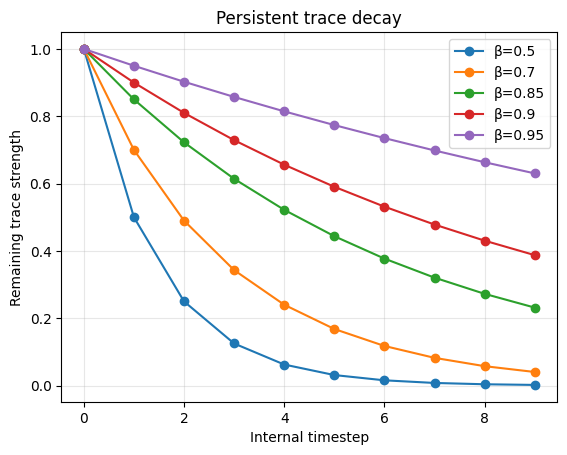

In [55]:
betas = [0.5, 0.7, 0.85, 0.9, 0.95]
num_steps = 10

for beta in betas:
    values = [beta ** t for t in range(num_steps)]
    plt.plot(range(num_steps), values, marker="o", label=f"β={beta}")

plt.xlabel("Internal timestep")
plt.ylabel("Remaining trace strength")
plt.title("Persistent trace decay")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Initial observations

- A one-timestep MNIST input produces the expected exponentially decaying visual trace.
- For $t>0$, the physical input is zero; persistence comes entirely from the memory state.
- The implementation matches the expected decay $M_t = \beta^t I_0$.
- Larger $\beta$ values preserve the visual signal for more internal timesteps.

Next: feed the persistent trace sequence into a small convolutional SNN and test whether temporal persistence improves reliable classification.


In [146]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

In [147]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([128, 1, 28, 28])
Labels: torch.Size([128])


In [148]:
trace_beta = 0.9

batch_trace = persistent_trace(
    images,
    beta=trace_beta,
    num_steps=8,
)

print(batch_trace.shape)

torch.Size([8, 128, 1, 28, 28])


Now we build a small SNN


In [149]:
import snntorch as snn
from snntorch import surrogate

import torch.nn as nn

In [150]:
class PersistentTraceSNN(nn.Module):
    def __init__(self, lif_beta=0.9):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=12,
            kernel_size=5,
            padding=2,
        )

        self.lif1 = snn.Leaky(
            beta=lif_beta,
            spike_grad=spike_grad,
        )

        self.pool = nn.MaxPool2d(2)

        self.fc = nn.Linear(
            12 * 14 * 14,
            10,
        )

        self.lif_out = snn.Leaky(
            beta=lif_beta,
            spike_grad=spike_grad,
        )
    def forward(self, trace):
        num_steps = trace.shape[0]
        batch_size = trace.shape[1]

        mem1 = self.lif1.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_out_rec = []
        mem_out_rec = []

        for t in range(num_steps):
            x = trace[t]

            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            x = self.pool(spk1)
            x = x.flatten(start_dim=1)

            cur_out = self.fc(x)
            spk_out, mem_out = self.lif_out(cur_out, mem_out)

            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        return (
            torch.stack(spk_out_rec),
            torch.stack(mem_out_rec),
        )

In [151]:
model = PersistentTraceSNN(lif_beta=0.9).to(device)

print(model)

PersistentTraceSNN(
  (conv1): Conv2d(1, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (lif1): Leaky()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2352, out_features=10, bias=True)
  (lif_out): Leaky()
)


In [152]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

batch_trace = persistent_trace(
    images,
    beta=0.9,
    num_steps=8,
).to(device)

In [153]:
spk_out, mem_out = model(batch_trace)

print("Output spike shape:", spk_out.shape)
print("Output membrane shape:", mem_out.shape)

Output spike shape: torch.Size([8, 128, 10])
Output membrane shape: torch.Size([8, 128, 10])


In [154]:
spike_counts = spk_out.sum(dim=0)

print(spike_counts.shape)
print(spike_counts[0])

torch.Size([128, 10])
tensor([0., 2., 0., 0., 0., 0., 0., 0., 0., 0.], device='mps:0',
       grad_fn=<SelectBackward0>)


In [155]:
zero_spike_samples = (spike_counts.sum(dim=1) == 0)

zero_spike_rate = zero_spike_samples.float().mean().item()

print("Zero-spike rate:", zero_spike_rate)

Zero-spike rate: 0.265625


In [ ]:
total_spikes_per_sample = spike_counts.sum(dim=1)

print("Mean output spikes per sample:",
      total_spikes_per_sample.float().mean().item())

print("Min output spikes:",
      total_spikes_per_sample.min().item())

print("Max output spikes:",
      total_spikes_per_sample.max().item())

Mean output spikes per sample: 1.0546875
Min output spikes: 0.0
Max output spikes: 3.0


In [157]:
import torch.optim as optim

learning_rate = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
)

In [158]:
criterion = nn.CrossEntropyLoss()

In [159]:
spk_out, mem_out = model(batch_trace)

spike_counts = spk_out.sum(dim=0)

loss = criterion(spike_counts, labels)

In [160]:
num_epochs = 3

trace_beta = 0.9
num_steps = 8

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_trace = persistent_trace(
            images,
            beta=trace_beta,
            num_steps=num_steps,
        )

        optimizer.zero_grad()

        spk_out, mem_out = model(batch_trace)

        spike_counts = spk_out.sum(dim=0)

        loss = criterion(
            spike_counts,
            labels,
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = spike_counts.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/3 | Loss: 0.3333 | Accuracy: 0.8999
Epoch 2/3 | Loss: 0.1151 | Accuracy: 0.9701
Epoch 3/3 | Loss: 0.0900 | Accuracy: 0.9772


In [161]:
model.eval()

test_correct = 0
test_total = 0

total_output_spikes = 0
zero_spike_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_trace = persistent_trace(
            images,
            beta=trace_beta,
            num_steps=num_steps,
        )

        spk_out, mem_out = model(batch_trace)

        spike_counts = spk_out.sum(dim=0)

        predictions = spike_counts.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        spikes_per_sample = spike_counts.sum(dim=1)

        total_output_spikes += spikes_per_sample.sum().item()
        zero_spike_samples += (spikes_per_sample == 0).sum().item()

test_accuracy = test_correct / test_total
mean_output_spikes = total_output_spikes / test_total
zero_spike_rate = zero_spike_samples / test_total

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Mean output spikes per sample: {mean_output_spikes:.4f}")
print(f"Zero-spike rate: {zero_spike_rate:.4f}")

Test accuracy: 0.9782
Mean output spikes per sample: 9.1848
Zero-spike rate: 0.0000


## Checkpoint: First persistent-trace classifier result

We successfully trained a small convolutional SNN using a one-timestep MNIST input followed by a decaying persistent visual trace.

### Current setup

- Physical input is present only at $t=0$.
- Persistent trace dynamics:

$$
M_t = \beta_{\text{trace}} M_{t-1} + I_t
$$

- Current trace persistence: $\beta_{\text{trace}} = 0.9$
- LIF membrane decay: $\beta_{\text{LIF}} = 0.9$
- Internal timesteps: $T = 8$
- Output layer: 10 spiking neurons, one per MNIST class
- Prediction is based on total output spikes accumulated across all internal timesteps.

### Training result

After 3 epochs:

- Epoch 1 accuracy: 89.99%
- Epoch 2 accuracy: 97.01%
- Epoch 3 accuracy: 97.72%

### Test result

- Test accuracy: 97.82%
- Mean output spikes per sample: 9.18
- Zero-spike rate: 0.00%

### Interpretation

This shows that a one-timestep visual input combined with a persistent decaying trace can support reliable MNIST classification with an SNN.

However, this does **not yet show that persistence itself is necessary or beneficial**.

The current model was trained using $\beta_{\text{trace}} = 0.9$, so the next experiment should compare it against a no-persistence baseline.

For the baseline:

$$
\beta_{\text{trace}} = 0
$$

which gives:

$$
M_0 = I_0
$$

and for $t>0$:

$$
M_t = 0
$$

The next step is therefore to train a fresh model with the same architecture and training settings, but with no persistent visual trace.

In [162]:
torch.manual_seed(SEED)
np.random.seed(SEED)

baseline_model = PersistentTraceSNN(
    lif_beta=0.9
).to(device)

In [163]:
baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=1e-3,
)

criterion = nn.CrossEntropyLoss()

In [164]:
baseline_trace_beta = 0.0
num_steps = 8
num_epochs = 3

In [165]:
for epoch in range(num_epochs):
    baseline_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_trace = persistent_trace(
            images,
            beta=baseline_trace_beta,
            num_steps=num_steps,
        )

        baseline_optimizer.zero_grad()

        spk_out, mem_out = baseline_model(batch_trace)

        spike_counts = spk_out.sum(dim=0)

        loss = criterion(
            spike_counts,
            labels,
        )

        loss.backward()
        baseline_optimizer.step()

        running_loss += loss.item()

        predictions = spike_counts.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/3 | Loss: 0.5763 | Accuracy: 0.8274
Epoch 2/3 | Loss: 0.2558 | Accuracy: 0.9273
Epoch 3/3 | Loss: 0.1839 | Accuracy: 0.9488


In [166]:
baseline_model.eval()

test_correct = 0
test_total = 0

total_output_spikes = 0
zero_spike_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_trace = persistent_trace(
            images,
            beta=baseline_trace_beta,
            num_steps=num_steps,
        )

        spk_out, mem_out = baseline_model(batch_trace)

        spike_counts = spk_out.sum(dim=0)
        predictions = spike_counts.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        spikes_per_sample = spike_counts.sum(dim=1)

        total_output_spikes += spikes_per_sample.sum().item()
        zero_spike_samples += (spikes_per_sample == 0).sum().item()

baseline_test_accuracy = test_correct / test_total
baseline_mean_spikes = total_output_spikes / test_total
baseline_zero_spike_rate = zero_spike_samples / test_total

print(f"Baseline test accuracy: {baseline_test_accuracy:.4f}")
print(f"Baseline mean output spikes per sample: {baseline_mean_spikes:.4f}")
print(f"Baseline zero-spike rate: {baseline_zero_spike_rate:.4f}")

Baseline test accuracy: 0.9570
Baseline mean output spikes per sample: 16.5154
Baseline zero-spike rate: 0.0000


## Baseline comparison: no persistence vs persistent trace

We trained a fresh SNN with the same architecture and training settings, but with no persistent visual trace.

### No-persistence baseline

For the baseline:

$$
\beta_{\text{trace}} = 0
$$

so the digit is present only at $t=0$, and the visual input is zero for all later internal timesteps.

Results:

- Test accuracy: 95.70%
- Mean output spikes per sample: 16.52
- Zero-spike rate: 0.00%

### Persistent-trace model

With:

$$
\beta_{\text{trace}} = 0.9
$$

results were:

- Test accuracy: 97.82%
- Mean output spikes per sample: 9.18
- Zero-spike rate: 0.00%

### Initial interpretation

In this first comparison, visual persistence improved test accuracy by about 2.1 percentage points while also reducing mean output spike count.

This suggests that persistent visual input may provide useful temporal evidence to the SNN rather than simply increasing network activity.

However, this is still only one comparison. The next step should be to systematically test several values of $\beta_{\text{trace}}$ using the same architecture and training procedure.

## Event-like input baseline

The previous experiments presented the original grayscale MNIST image directly to the first convolutional layer.

This means each pixel supplied an analog intensity value between 0 and 1.

For a more neuromorphic input representation, we now convert each MNIST image into a binary spatial event map:

$$
E(x,y) =
\begin{cases}
1, & I(x,y) > \theta \\
0, & I(x,y) \leq \theta
\end{cases}
$$

Each active pixel can therefore contribute at most one event during the physical input timestep.

This is still a simplified event representation. A real event camera responds to temporal changes in brightness and also provides event timing and polarity. Here we first study the simpler question of whether a one-shot binary spatial event pattern contains enough information for classification.